In [2]:
import rdkit
from rdkit import DataStructs, Chem
from rdkit.Chem import AllChem
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

# TM-60 and CM-60 PCAs

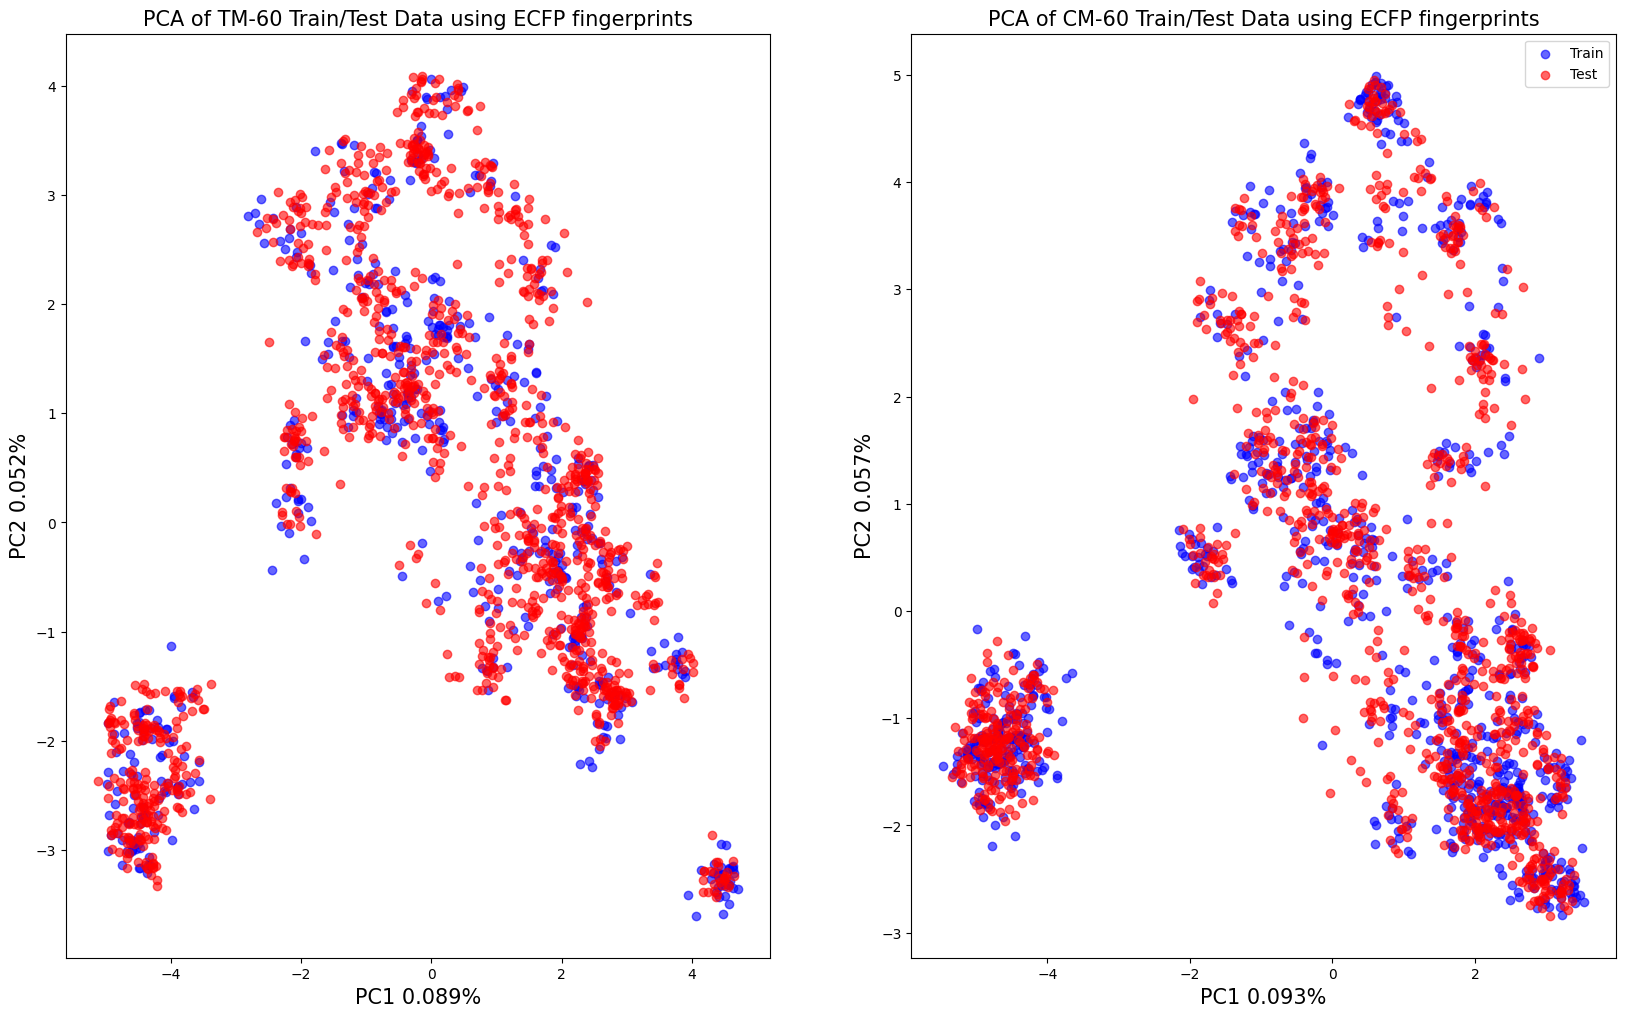

In [ ]:
def smiles_to_ecfp(smiles_list, radius=3, n_bits=2048):             # function to convert SMILES to ECFP fingerprints
    fingerprints = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            fingerprints.append(np.array(fp))
        else:
            continue 
    return np.array(fingerprints)


train = pd.read_csv(r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_train_NM-RS42.csv')               # load in train/test data
test = pd.read_csv(r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_test_NM-RS42.csv')

train['Set'] = 'train'  
test['Set']  = 'test'

smiles_train = train['Structure']               # extract SMILES
smiles_test = test['Structure']

X_train_fp = smiles_to_ecfp(smiles_train)       # convert SMILES to ECFP
X_test_fp = smiles_to_ecfp(smiles_test)

pca = PCA(n_components=2)                       # create PCA instance

X_train_pca = pca.fit_transform(X_train_fp)     # fit the PCA to the train and transform both train and test into PCA space
X_test_pca = pca.transform(X_test_fp)


col_train = pd.read_csv(r'M:\ML_scripts\MODEL DATA\colistin models_data\colistin_training_set.csv')     # same process for colistin data
col_test = pd.read_csv(r'M:\ML_scripts\MODEL DATA\colistin models_data\colistin_testing_set.csv')

col_smiles_train = col_train['Structure']
col_smiles_test = col_test['Structure']

col_X_train_fp = smiles_to_ecfp(col_smiles_train)
col_X_test_fp = smiles_to_ecfp(col_smiles_test)

col_pca = PCA(n_components=2)

col_X_train_pca = col_pca.fit_transform(col_X_train_fp)
col_X_test_pca = col_pca.transform(col_X_test_fp)


fig, axs = plt.subplots(1,2, figsize=(20,12))               # create subplots

plt.subplot(121)

axs[0].scatter(X_train_pca[:, 0], X_train_pca[:, 1], label='Train', alpha=0.6, color='blue')        # plot the 'X' and 'y' coords from the PCA output
axs[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], label='Test', alpha=0.6, color='red')


plt.xlabel(f'PC1 {pca.explained_variance_ratio_[0]:.3f}%', fontsize=15)                             # include the variance component ratios on the axes
plt.ylabel(f'PC2 {pca.explained_variance_ratio_[1]:.3f}%', fontsize=15)
plt.title('PCA of TM-60 Train/Test Data using ECFP fingerprints', fontsize=15)

plt.subplot(122)

axs[1].scatter(col_X_train_pca[:, 0], col_X_train_pca[:, 1], label='Train', alpha=0.6, color='blue')
axs[1].scatter(col_X_test_pca[:, 0], col_X_test_pca[:, 1], label='Test', alpha=0.6, color='red')


plt.xlabel(f'PC1 {col_pca.explained_variance_ratio_[0]:.3f}%', fontsize=15)
plt.ylabel(f'PC2 {col_pca.explained_variance_ratio_[1]:.3f}%', fontsize=15)
plt.title('PCA of CM-60 Train/Test Data using ECFP fingerprints', fontsize=15)

plt.legend()
plt.show()